In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.metrics import (
    precision_recall_curve,
    roc_curve,
)

PROJECT_ROOT = Path("/Users/user/Documents/trustlens")

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
METRICS_DIR = RESULTS_DIR / "metrics"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

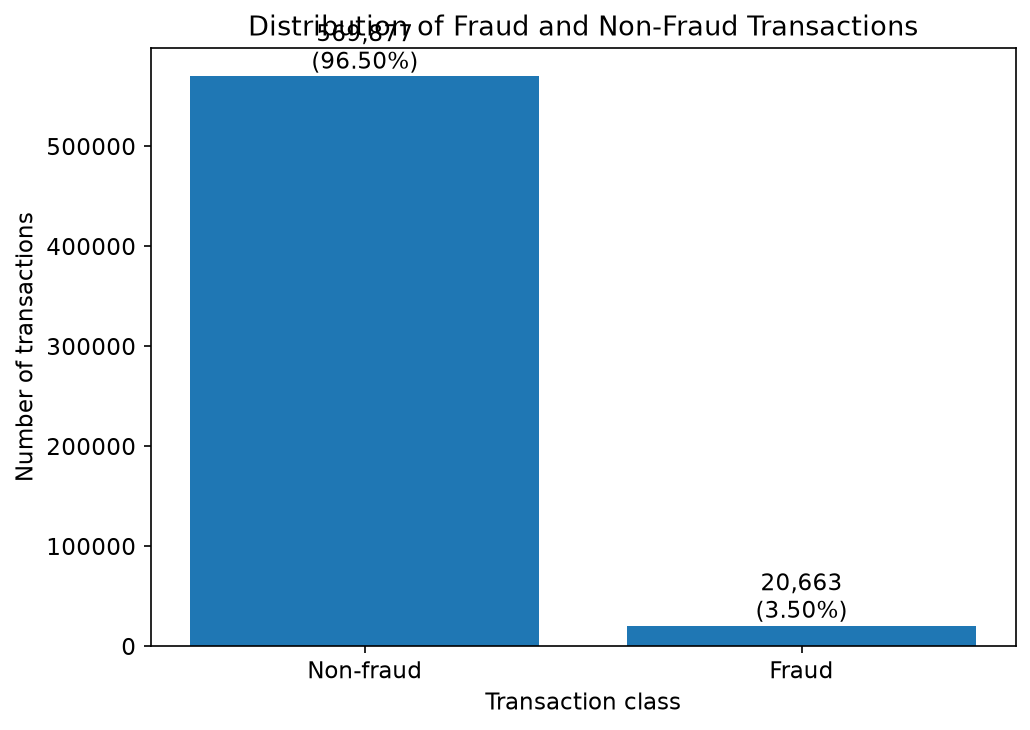

Saved to: /Users/user/Documents/trustlens/results/figures/fraud_class_distribution.png


In [2]:
class_counts = pd.Series(
    {
        "Non-fraud": 569_877,
        "Fraud": 20_663,
    }
)

class_percentages = class_counts / class_counts.sum() * 100

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    class_counts.index,
    class_counts.values,
)

ax.set_title("Distribution of Fraud and Non-Fraud Transactions")
ax.set_xlabel("Transaction class")
ax.set_ylabel("Number of transactions")

for bar, count, percentage in zip(
    bars,
    class_counts.values,
    class_percentages.values,
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}\n({percentage:.2f}%)",
        ha="center",
        va="bottom",
    )

ax.ticklabel_format(
    axis="y",
    style="plain",
)

fig.tight_layout()

output_path = FIGURES_DIR / "fraud_class_distribution.png"

fig.savefig(
    output_path,
    bbox_inches="tight",
    transparent=False,
)

plt.show()

print(f"Saved to: {output_path}")

In [3]:
missing_df = pd.read_csv(
    METRICS_DIR / "missing_values_summary.csv"
)

print(missing_df.columns.tolist())
display(missing_df.head())

['feature', 'missing_percentage']


,feature,missing_percentage
0,id_24,99.196159
1,id_25,99.130965
2,id_07,99.127070
3,id_08,99.127070
4,id_21,99.126393


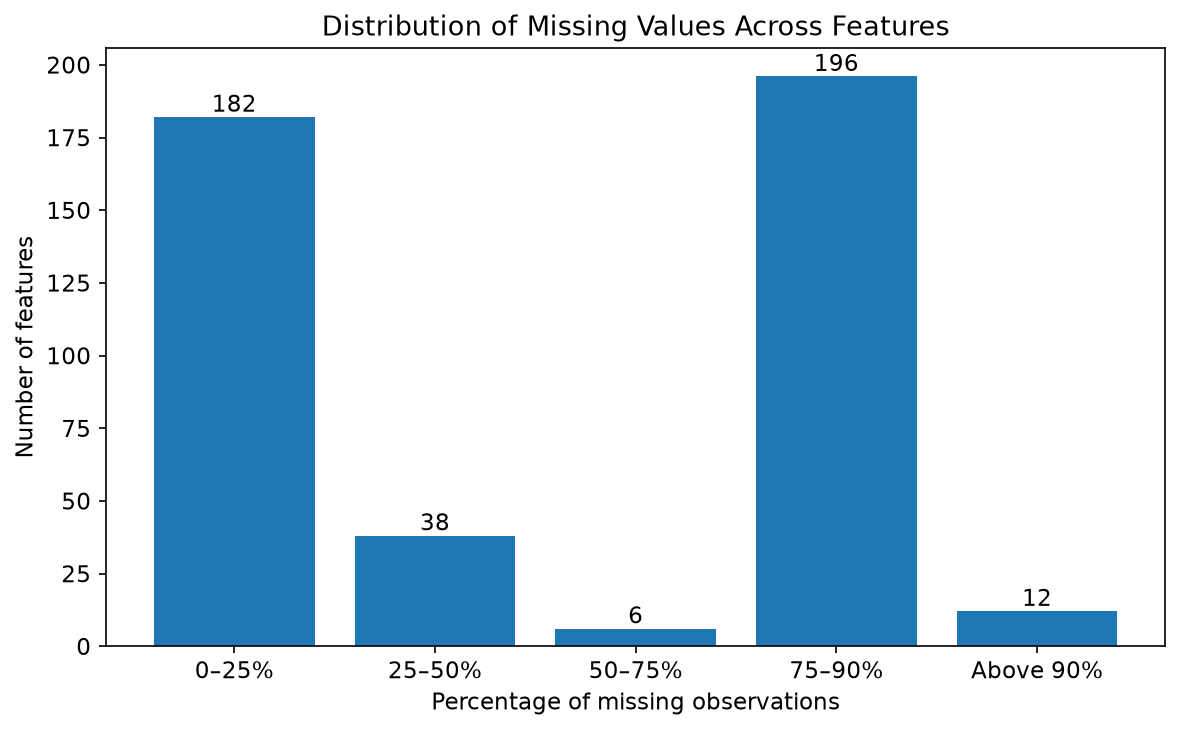

Saved to: /Users/user/Documents/trustlens/results/figures/missing_value_distribution.png


In [4]:
missing_df = pd.read_csv(
    METRICS_DIR / "missing_values_summary.csv"
)

percentage_candidates = [
    "missing_percentage",
    "missing_percent",
    "missing_pct",
    "percentage_missing",
    "Missing Percentage",
]

percentage_column = next(
    (
        column
        for column in percentage_candidates
        if column in missing_df.columns
    ),
    None,
)

if percentage_column is None:
    raise ValueError(
        "Could not identify the missing-percentage column. "
        f"Available columns: {missing_df.columns.tolist()}"
    )

missing_percentages = pd.to_numeric(
    missing_df[percentage_column],
    errors="coerce",
).dropna()

bins = [0, 25, 50, 75, 90, 100.0001]

labels = [
    "0–25%",
    "25–50%",
    "50–75%",
    "75–90%",
    "Above 90%",
]

missing_groups = pd.cut(
    missing_percentages,
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=False,
)

group_counts = (
    missing_groups
    .value_counts(sort=False)
    .reindex(labels, fill_value=0)
)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    group_counts.index,
    group_counts.values,
)

ax.set_title("Distribution of Missing Values Across Features")
ax.set_xlabel("Percentage of missing observations")
ax.set_ylabel("Number of features")

for bar, count in zip(bars, group_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        str(int(count)),
        ha="center",
        va="bottom",
    )

fig.tight_layout()

output_path = FIGURES_DIR / "missing_value_distribution.png"

fig.savefig(
    output_path,
    bbox_inches="tight",
)

plt.show()

print(f"Saved to: {output_path}")

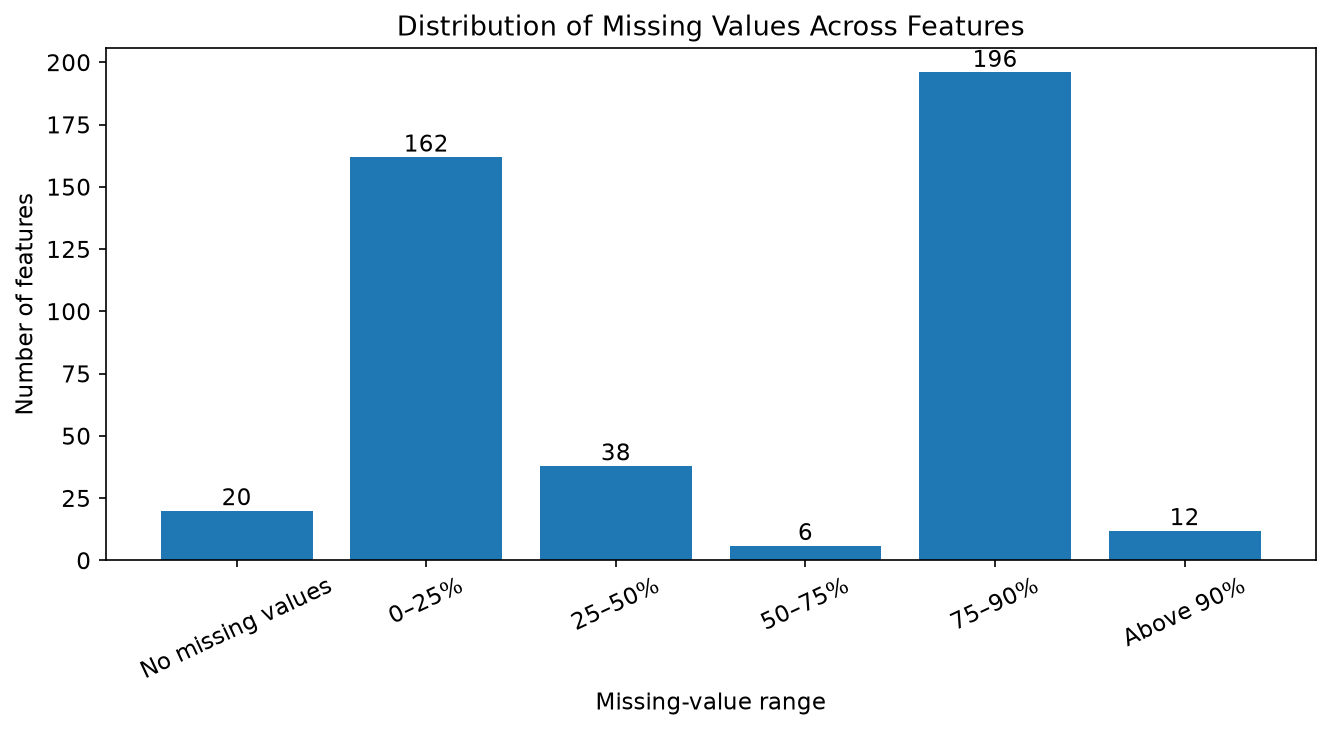

Saved to: /Users/user/Documents/trustlens/results/figures/missing_value_distribution.png


In [5]:
missing_group_counts = pd.Series(
    {
        "No missing values": 20,
        "0–25%": 162,
        "25–50%": 38,
        "50–75%": 6,
        "75–90%": 196,
        "Above 90%": 12,
    }
)

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    missing_group_counts.index,
    missing_group_counts.values,
)

ax.set_title("Distribution of Missing Values Across Features")
ax.set_xlabel("Missing-value range")
ax.set_ylabel("Number of features")

ax.tick_params(
    axis="x",
    rotation=25,
)

for bar, count in zip(
    bars,
    missing_group_counts.values,
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        str(count),
        ha="center",
        va="bottom",
    )

fig.tight_layout()

output_path = FIGURES_DIR / "missing_value_distribution.png"

fig.savefig(
    output_path,
    bbox_inches="tight",
)

plt.show()

print(f"Saved to: {output_path}")

In [6]:
transaction_path = DATA_DIR / "raw" / "train_transaction.csv"

transaction_df = pd.read_csv(
    transaction_path,
    usecols=["TransactionAmt", "isFraud"],
)

transaction_df["TransactionAmt"] = pd.to_numeric(
    transaction_df["TransactionAmt"],
    errors="coerce",
)

transaction_df = transaction_df.dropna(
    subset=["TransactionAmt", "isFraud"]
)

display(
    transaction_df.groupby("isFraud")["TransactionAmt"]
    .agg(["count", "mean", "median", "min", "max"])
)

,count,mean,median,min,max
isFraud,,,,,
0,569877,134.511665,68.5,0.251,31937.391
1,20663,149.244779,75.0,0.292,5191.000


/Users/user/Documents/trustlens/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


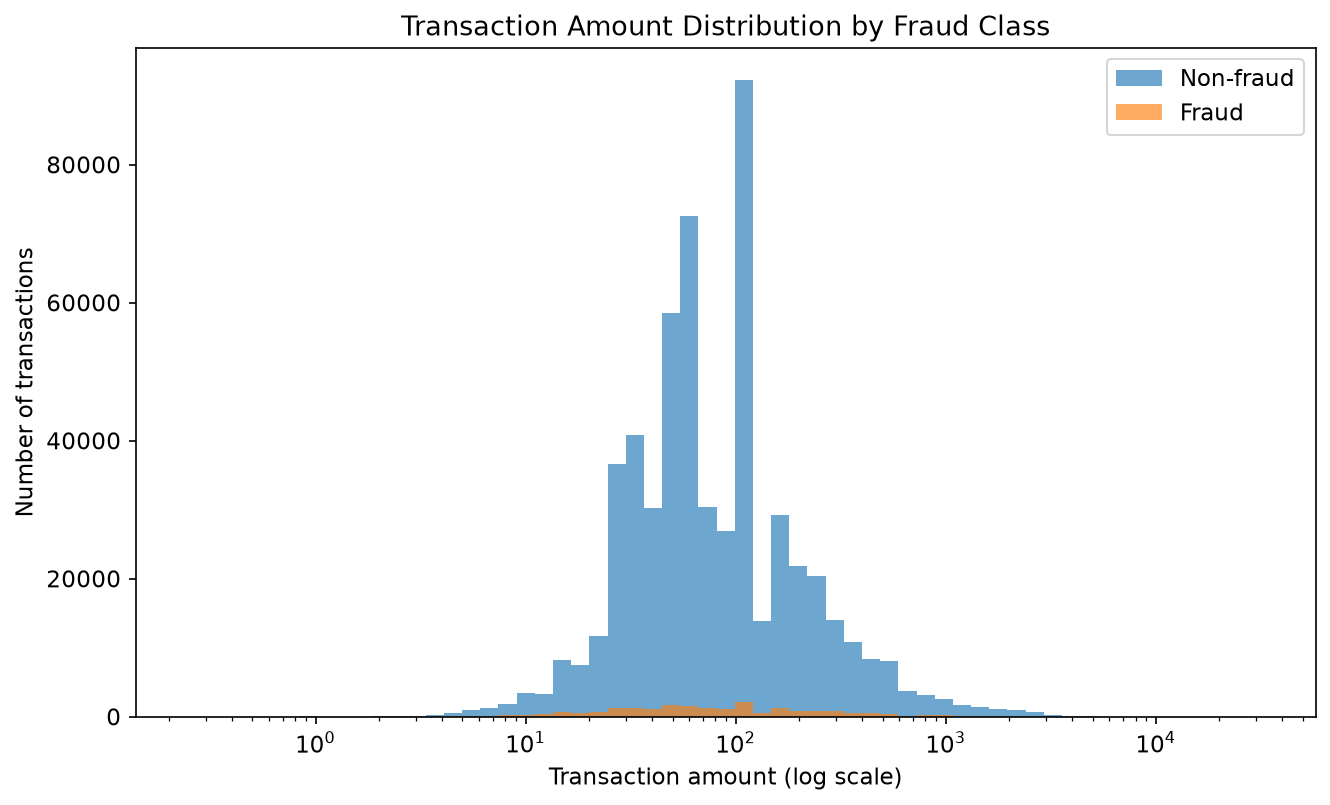

Saved to: /Users/user/Documents/trustlens/results/figures/transaction_amount_distribution.png


In [7]:
non_fraud_amounts = transaction_df.loc[
    transaction_df["isFraud"] == 0,
    "TransactionAmt",
]

fraud_amounts = transaction_df.loc[
    transaction_df["isFraud"] == 1,
    "TransactionAmt",
]

positive_amounts = transaction_df.loc[
    transaction_df["TransactionAmt"] > 0,
    "TransactionAmt",
]

log_bins = np.logspace(
    np.log10(positive_amounts.min()),
    np.log10(positive_amounts.max()),
    60,
)

fig, ax = plt.subplots(figsize=(9, 5.5))

ax.hist(
    non_fraud_amounts[non_fraud_amounts > 0],
    bins=log_bins,
    alpha=0.65,
    label="Non-fraud",
)

ax.hist(
    fraud_amounts[fraud_amounts > 0],
    bins=log_bins,
    alpha=0.65,
    label="Fraud",
)

ax.set_xscale("log")

ax.set_title(
    "Transaction Amount Distribution by Fraud Class"
)

ax.set_xlabel(
    "Transaction amount (log scale)"
)

ax.set_ylabel(
    "Number of transactions"
)

ax.legend()

fig.tight_layout()

output_path = (
    FIGURES_DIR
    / "transaction_amount_distribution.png"
)

fig.savefig(
    output_path,
    bbox_inches="tight",
)

plt.show()

print(f"Saved to: {output_path}")

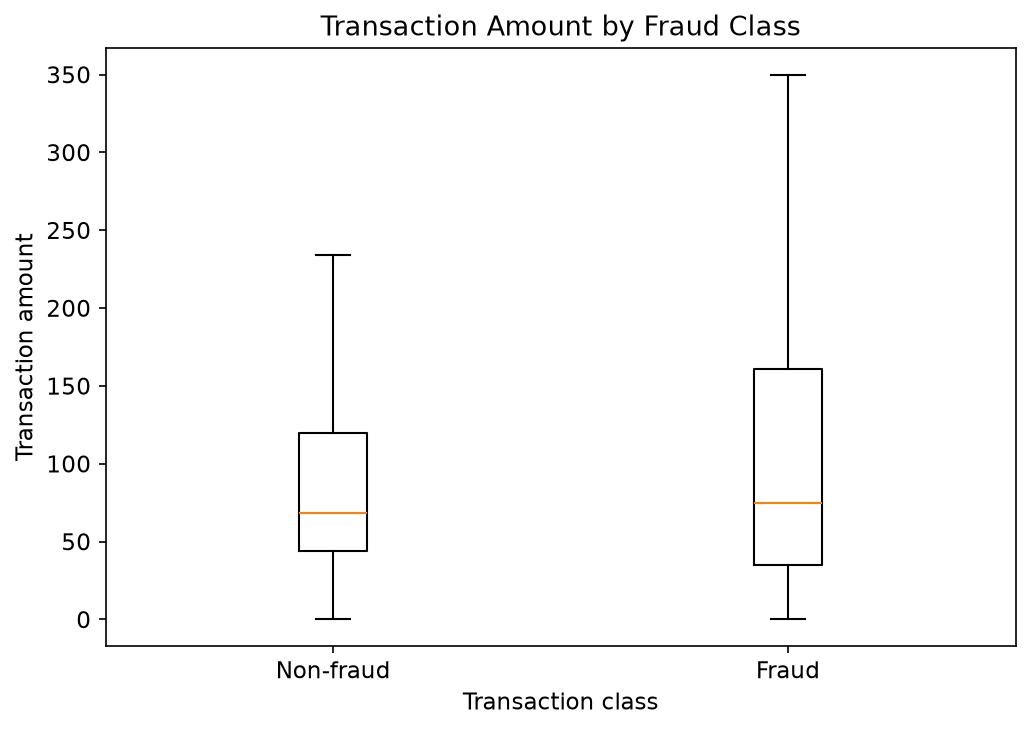

Saved to: /Users/user/Documents/trustlens/results/figures/transaction_amount_boxplot.png


In [8]:
plot_data = [
    non_fraud_amounts,
    fraud_amounts,
]

fig, ax = plt.subplots(figsize=(7, 5))

ax.boxplot(
    plot_data,
    tick_labels=["Non-fraud", "Fraud"],
    showfliers=False,
)

ax.set_title(
    "Transaction Amount by Fraud Class"
)

ax.set_xlabel(
    "Transaction class"
)

ax.set_ylabel(
    "Transaction amount"
)

fig.tight_layout()

output_path = (
    FIGURES_DIR
    / "transaction_amount_boxplot.png"
)

fig.savefig(
    output_path,
    bbox_inches="tight",
)

plt.show()

print(f"Saved to: {output_path}")

In [9]:
comparison_df = pd.read_csv(
    METRICS_DIR / "trustlens_model_comparison_table.csv"
)

print(comparison_df.columns.tolist())
display(comparison_df)

['model', 'accuracy', 'precision', 'recall', 'f1_score', 'roc_auc', 'pr_auc', 'mcc', 'training_time_seconds', 'prediction_time_seconds', 'interpretation_method', 'shap_explanation_time_500_samples']


,model,accuracy,precision,recall,f1_score,roc_auc,pr_auc,mcc,training_time_seconds,prediction_time_seconds,interpretation_method,shap_explanation_time_500_samples
0,Logistic Regression,0.664663,0.069471,0.692475,0.126274,0.752129,0.137994,0.137315,279.490710,1.135424,Model Coefficients,NaN
1,Random Forest,0.894453,0.211840,0.741108,0.329497,0.898592,0.561090,0.359440,81.168540,1.498031,SHAP,27.880723
2,LightGBM,0.923832,0.294827,0.845391,0.437187,0.954846,0.720748,0.472212,41.225751,2.660839,SHAP,3.411595
3,XGBoost,0.905756,0.246008,0.819985,0.378469,0.937218,0.656367,0.417259,87.925848,0.692741,SHAP,0.467909


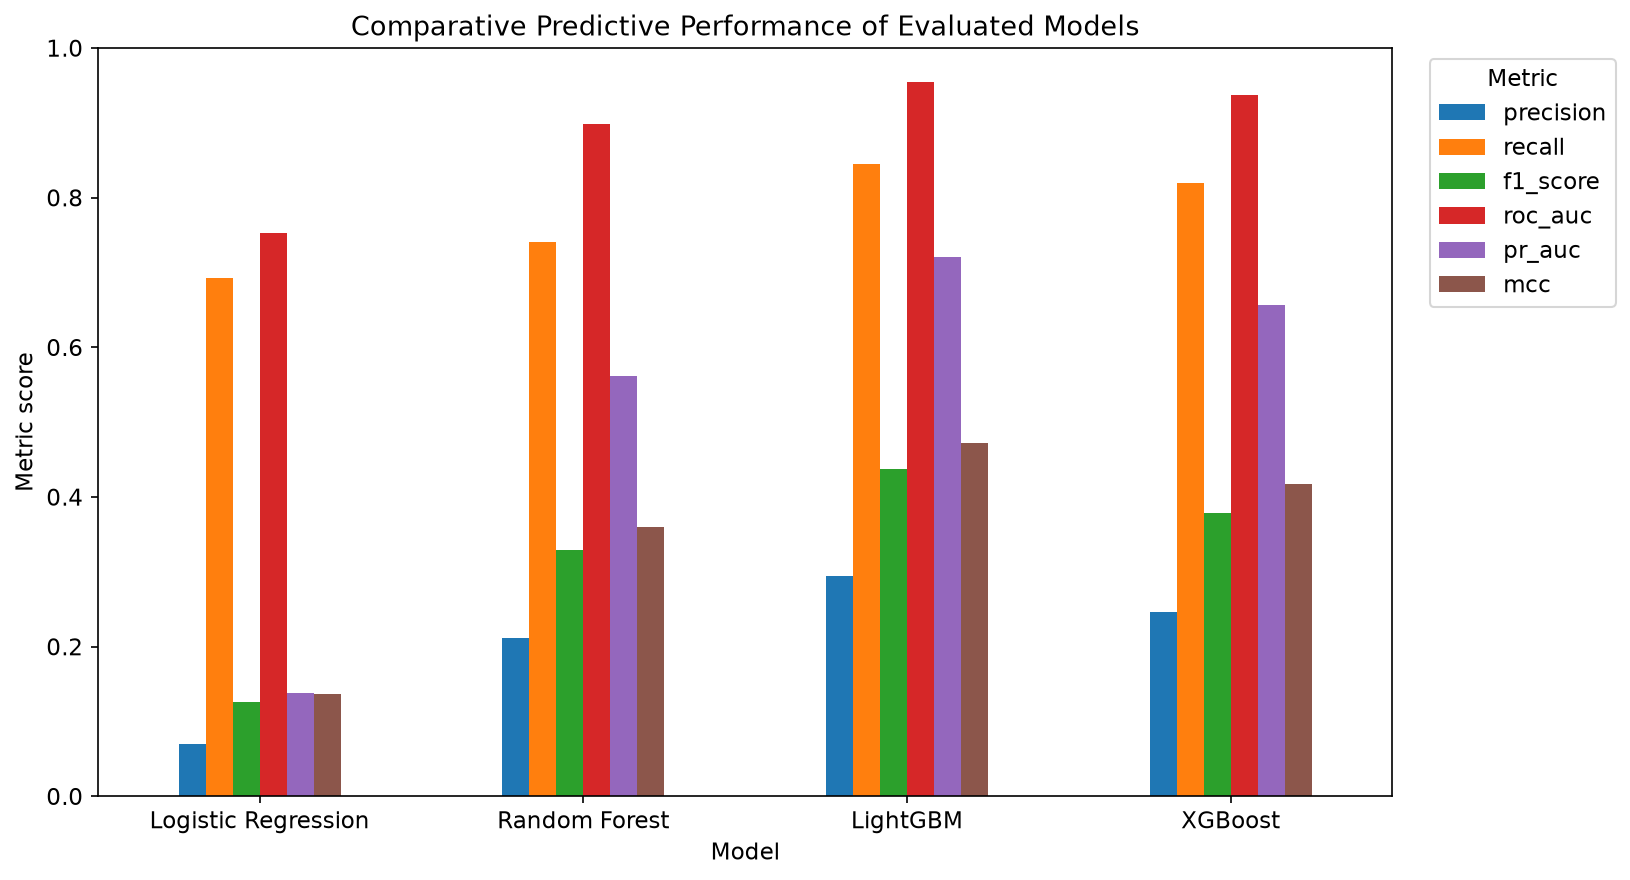

Saved to: /Users/user/Documents/trustlens/results/figures/comparative_model_performance.png


In [10]:
metric_columns = [
    "precision",
    "recall",
    "f1_score",
    "roc_auc",
    "pr_auc",
    "mcc",
]

available_metrics = [
    column
    for column in metric_columns
    if column in comparison_df.columns
]

if not available_metrics:
    raise ValueError(
        "No recognised metric columns were found. "
        f"Available columns: {comparison_df.columns.tolist()}"
    )

model_column_candidates = [
    "model",
    "Model",
    "model_name",
]

model_column = next(
    (
        column
        for column in model_column_candidates
        if column in comparison_df.columns
    ),
    None,
)

if model_column is None:
    raise ValueError(
        "Could not identify the model-name column."
    )

plot_df = (
    comparison_df
    .set_index(model_column)[available_metrics]
)

ax = plot_df.plot(
    kind="bar",
    figsize=(11, 6),
)

ax.set_title(
    "Comparative Predictive Performance of Evaluated Models"
)

ax.set_xlabel(
    "Model"
)

ax.set_ylabel(
    "Metric score"
)

ax.set_ylim(
    0,
    1,
)

ax.tick_params(
    axis="x",
    rotation=0,
)

ax.legend(
    title="Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

fig = ax.get_figure()

fig.tight_layout()

output_path = (
    FIGURES_DIR
    / "comparative_model_performance.png"
)

fig.savefig(
    output_path,
    bbox_inches="tight",
)

plt.show()

print(f"Saved to: {output_path}")

In [11]:
print(comparison_df.columns.tolist())

['model', 'accuracy', 'precision', 'recall', 'f1_score', 'roc_auc', 'pr_auc', 'mcc', 'training_time_seconds', 'prediction_time_seconds', 'interpretation_method', 'shap_explanation_time_500_samples']


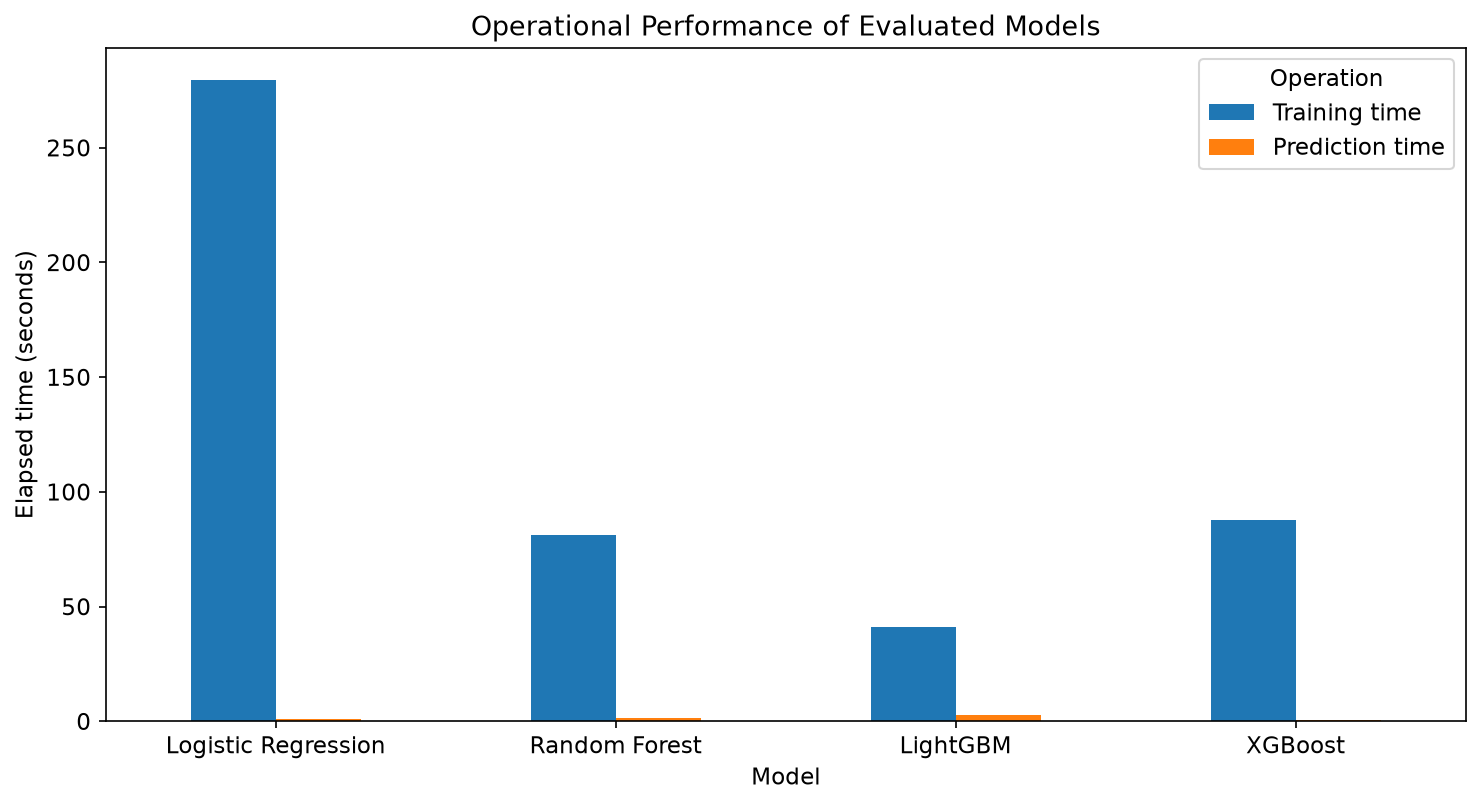

Saved to: /Users/user/Documents/trustlens/results/figures/operational_performance.png


In [12]:
timing_column_candidates = {
    "Training time": [
        "training_time_seconds",
        "training_time",
    ],
    "Prediction time": [
        "prediction_time_seconds",
        "prediction_time",
    ],
    "SHAP time": [
        "shap_time_seconds",
        "shap_explanation_time_seconds",
        "shap_time",
    ],
}

selected_timing_columns = {}

for display_name, candidates in timing_column_candidates.items():
    matching_column = next(
        (
            column
            for column in candidates
            if column in comparison_df.columns
        ),
        None,
    )

    if matching_column is not None:
        selected_timing_columns[display_name] = matching_column

if not selected_timing_columns:
    raise ValueError(
        "No timing columns were found. "
        f"Available columns: {comparison_df.columns.tolist()}"
    )

timing_df = comparison_df[
    [model_column, *selected_timing_columns.values()]
].copy()

timing_df = timing_df.rename(
    columns={
        value: key
        for key, value in selected_timing_columns.items()
    }
)

timing_df = timing_df.set_index(model_column)

ax = timing_df.plot(
    kind="bar",
    figsize=(10, 5.5),
)

ax.set_title(
    "Operational Performance of Evaluated Models"
)

ax.set_xlabel(
    "Model"
)

ax.set_ylabel(
    "Elapsed time (seconds)"
)

ax.tick_params(
    axis="x",
    rotation=0,
)

ax.legend(
    title="Operation"
)

fig = ax.get_figure()

fig.tight_layout()

output_path = (
    FIGURES_DIR
    / "operational_performance.png"
)

fig.savefig(
    output_path,
    bbox_inches="tight",
)

plt.show()

print(f"Saved to: {output_path}")

In [13]:
ax.set_yscale("log")

In [16]:
X_test = pd.read_csv(
    PROCESSED_DIR / "X_test_processed_no_id.csv"
)

y_test = pd.read_csv(
    PROCESSED_DIR / "y_test.csv"
).squeeze("columns")

In [17]:
models = {
    "Logistic Regression": joblib.load(
        MODELS_DIR / "logistic_regression_no_id.pkl"
    ),
    "Random Forest": joblib.load(
        MODELS_DIR / "random_forest_no_id.pkl"
    ),
    "LightGBM": joblib.load(
        MODELS_DIR / "lightgbm_no_id.pkl"
    ),
    "XGBoost": joblib.load(
        MODELS_DIR / "xgboost_no_id.pkl"
    ),
}

In [18]:
from pathlib import Path

import joblib
import pandas as pd

PROJECT_ROOT = Path("/Users/user/Documents/trustlens")

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"

X_test = pd.read_csv(
    PROCESSED_DIR / "X_test_processed_no_id.csv"
)

y_test = pd.read_csv(
    PROCESSED_DIR / "y_test.csv"
).squeeze("columns")

models = {
    "Logistic Regression": joblib.load(
        MODELS_DIR / "logistic_regression_no_id.pkl"
    ),
    "Random Forest": joblib.load(
        MODELS_DIR / "random_forest_no_id.pkl"
    ),
    "LightGBM": joblib.load(
        MODELS_DIR / "lightgbm_no_id.pkl"
    ),
    "XGBoost": joblib.load(
        MODELS_DIR / "xgboost_no_id.pkl"
    ),
}

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

for model_name, model in models.items():
    print(
        model_name,
        "expects",
        model.n_features_in_,
        "features"
    )

X_test shape: (118108, 420)
y_test shape: (118108,)
Logistic Regression expects 420 features
Random Forest expects 420 features
LightGBM expects 420 features
XGBoost expects 420 features


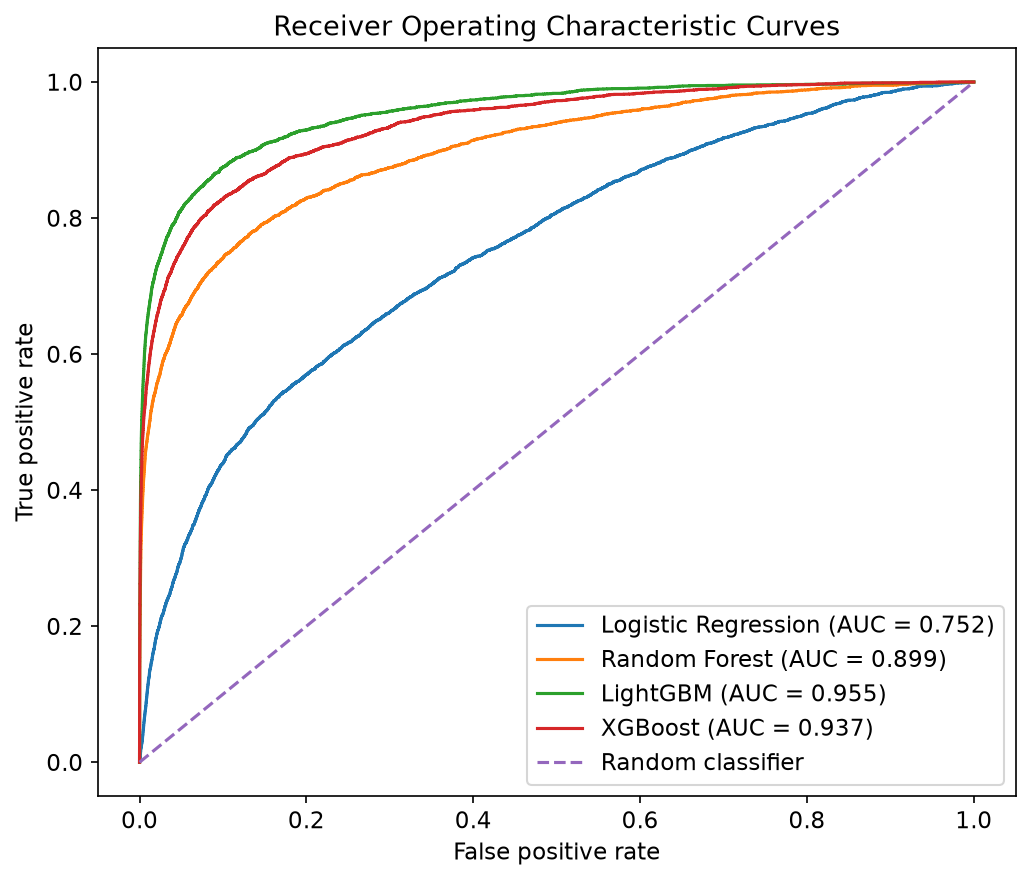

Saved to: /Users/user/Documents/trustlens/results/figures/roc_curves.png


In [19]:
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, roc_auc_score

probability_outputs = {}

fig, ax = plt.subplots(figsize=(7, 6))

for model_name, model in models.items():
    fraud_probabilities = model.predict_proba(
        X_test
    )[:, 1]

    probability_outputs[model_name] = (
        fraud_probabilities
    )

    false_positive_rate, true_positive_rate, _ = (
        roc_curve(
            y_test,
            fraud_probabilities,
        )
    )

    auc_value = roc_auc_score(
        y_test,
        fraud_probabilities,
    )

    ax.plot(
        false_positive_rate,
        true_positive_rate,
        label=f"{model_name} (AUC = {auc_value:.3f})",
    )

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier",
)

ax.set_title(
    "Receiver Operating Characteristic Curves"
)

ax.set_xlabel(
    "False positive rate"
)

ax.set_ylabel(
    "True positive rate"
)

ax.legend(
    loc="lower right"
)

fig.tight_layout()

output_path = (
    PROJECT_ROOT
    / "results"
    / "figures"
    / "roc_curves.png"
)

output_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)

fig.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Saved to: {output_path}")

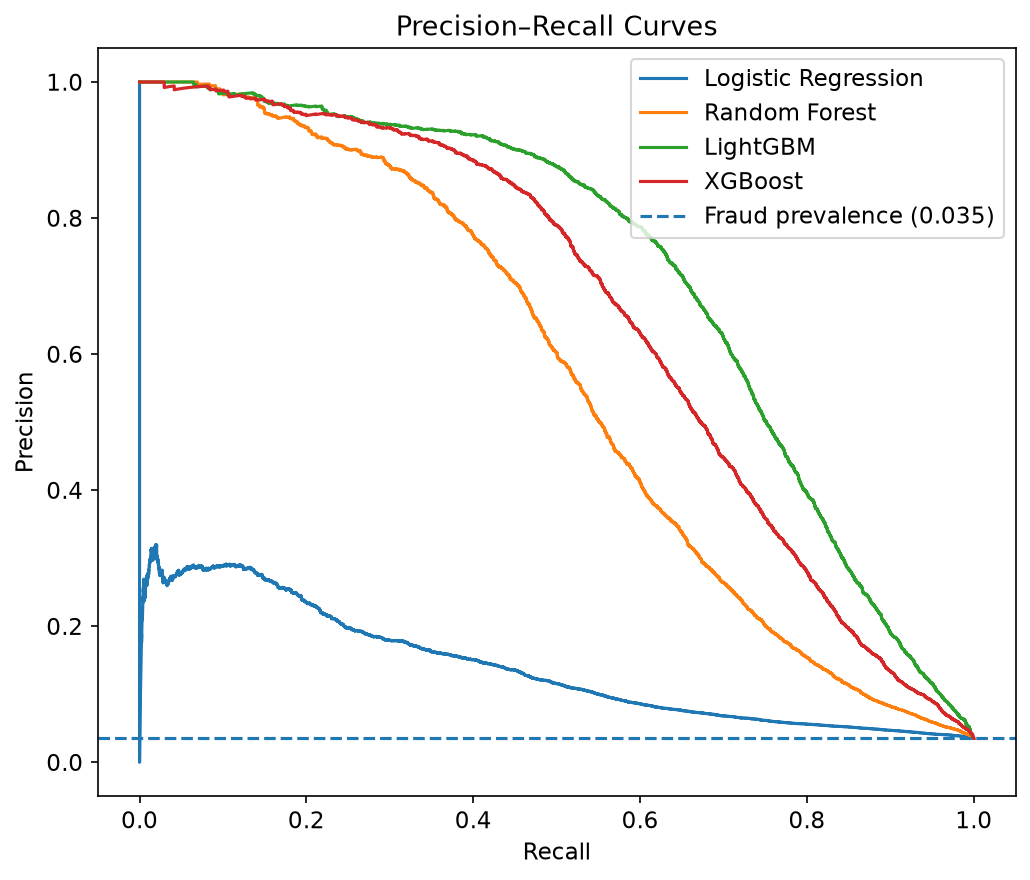

Saved to: /Users/user/Documents/trustlens/results/figures/precision_recall_curves.png


In [20]:
fig, ax = plt.subplots(figsize=(7, 6))

for model_name, fraud_probabilities in (
    probability_outputs.items()
):
    precision_values, recall_values, _ = (
        precision_recall_curve(
            y_test,
            fraud_probabilities,
        )
    )

    ax.plot(
        recall_values,
        precision_values,
        label=model_name,
    )

baseline_precision = y_test.mean()

ax.axhline(
    baseline_precision,
    linestyle="--",
    label=(
        f"Fraud prevalence "
        f"({baseline_precision:.3f})"
    ),
)

ax.set_title(
    "Precision–Recall Curves"
)

ax.set_xlabel(
    "Recall"
)

ax.set_ylabel(
    "Precision"
)

ax.legend(
    loc="upper right"
)

fig.tight_layout()

output_path = (
    FIGURES_DIR
    / "precision_recall_curves.png"
)

fig.savefig(
    output_path,
    bbox_inches="tight",
)

plt.show()

print(f"Saved to: {output_path}")

In [21]:
probability_df = pd.DataFrame({
    "actual_label": np.asarray(y_test),
    **{
        model_name: probabilities
        for model_name, probabilities
        in probability_outputs.items()
    },
})

probability_output_path = (
    METRICS_DIR
    / "test_prediction_probabilities.csv"
)

probability_df.to_csv(
    probability_output_path,
    index=False,
)

print(
    f"Saved probabilities to: "
    f"{probability_output_path}"
)

Saved probabilities to: /Users/user/Documents/trustlens/results/metrics/test_prediction_probabilities.csv


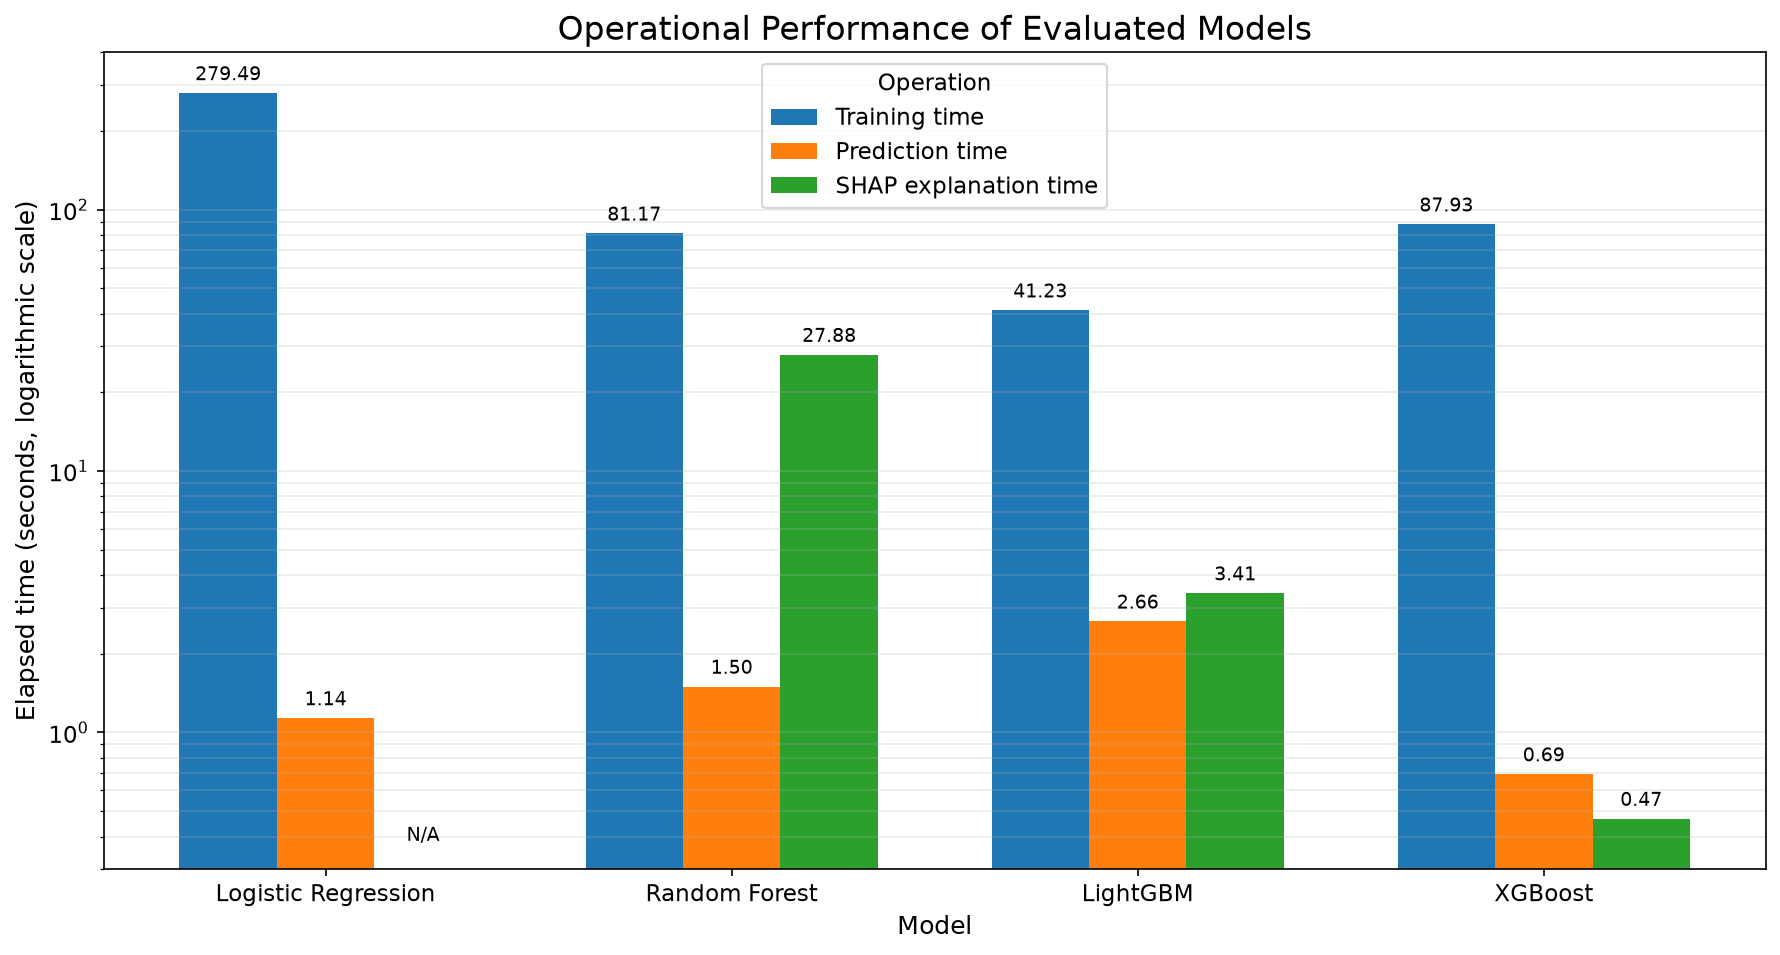

Chart saved to: ../results/figures/operational_performance_log_scale.png


In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Final operational-performance results
models = [
    "Logistic Regression",
    "Random Forest",
    "LightGBM",
    "XGBoost"
]

training_times = np.array([
    279.490710,
    81.168540,
    41.225751,
    87.925848
])

prediction_times = np.array([
    1.135424,
    1.498031,
    2.660839,
    0.692741
])

# Logistic Regression was interpreted using coefficients rather than SHAP
shap_times = np.array([
    np.nan,
    27.880723,
    3.411595,
    0.467909
])

# Bar positions
x = np.arange(len(models))
bar_width = 0.24

fig, ax = plt.subplots(figsize=(12, 6.5))

training_bars = ax.bar(
    x - bar_width,
    training_times,
    bar_width,
    label="Training time"
)

prediction_bars = ax.bar(
    x,
    prediction_times,
    bar_width,
    label="Prediction time"
)

shap_bars = ax.bar(
    x + bar_width,
    np.nan_to_num(shap_times, nan=0.0),
    bar_width,
    label="SHAP explanation time"
)

# A logarithmic scale prevents the larger training values
# from making prediction and SHAP bars appear invisible
ax.set_yscale("log")
ax.set_ylim(0.3, 400)

ax.set_title(
    "Operational Performance of Evaluated Models",
    fontsize=16
)
ax.set_xlabel("Model", fontsize=12)
ax.set_ylabel(
    "Elapsed time (seconds, logarithmic scale)",
    fontsize=12
)

ax.set_xticks(x)
ax.set_xticklabels(models)

ax.legend(title="Operation")
ax.grid(axis="y", which="both", alpha=0.25)


# Add values above each visible bar
def add_value_labels(bars, values):
    for bar, value in zip(bars, values):
        if np.isnan(value):
            continue

        ax.annotate(
            f"{value:.2f}",
            xy=(
                bar.get_x() + bar.get_width() / 2,
                value
            ),
            xytext=(0, 4),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9
        )


add_value_labels(training_bars, training_times)
add_value_labels(prediction_bars, prediction_times)
add_value_labels(shap_bars, shap_times)

# Show that SHAP timing was not applicable to Logistic Regression
ax.annotate(
    "N/A",
    xy=(x[0] + bar_width, 0.37),
    ha="center",
    va="bottom",
    fontsize=9
)

plt.tight_layout()

# Change this path if your figures folder is elsewhere
output_path = "../results/figures/operational_performance_log_scale.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Chart saved to: {output_path}")